### Анализ тональности

#### Загрузка данных и пакетов

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [16]:
df.shape

(41157, 6)

#### Вывод случайных значений

In [17]:
df.sample(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
21615,25414,70366,"England, United Kingdom",25-03-2020,@BorisJohnson I'm trying Guv'nor but shopping ...,Neutral
37098,40897,85849,"South West, England",10-04-2020,@CornwallLive I was in my local supermarket ye...,Extremely Negative
18424,22223,67175,"England, United Kingdom",23-03-2020,?This is another awful consequence of the #cor...,Extremely Negative
28860,32659,77611,Melbourne,05-04-2020,It s time to institute standard safety practic...,Extremely Positive
20401,24200,69152,"Meerut, India",25-03-2020,All the respected consumer of PVVNL are reques...,Extremely Positive
12873,16672,61624,"London, England",21-03-2020,Central Banks cut rates in emergency bid to st...,Negative
23492,27291,72243,"Stoke-on-Trent, England",26-03-2020,Do you work in a gang and also hire in toilets...,Neutral
22504,26303,71255,"Abuja, Nigeria",25-03-2020,@TosinOlugbenga Can we all stop panicking and ...,Extremely Negative
11115,14914,59866,ATX/Nville,20-03-2020,Seriously just heard of a friend planning on e...,Positive
17595,21394,66346,Dar es Salaam,23-03-2020,"Be reminded that, not all hand sanitizers can ...",Positive


In [18]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df[['OriginalTweet', 'Sentiment']]
df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


#### Визуализация

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


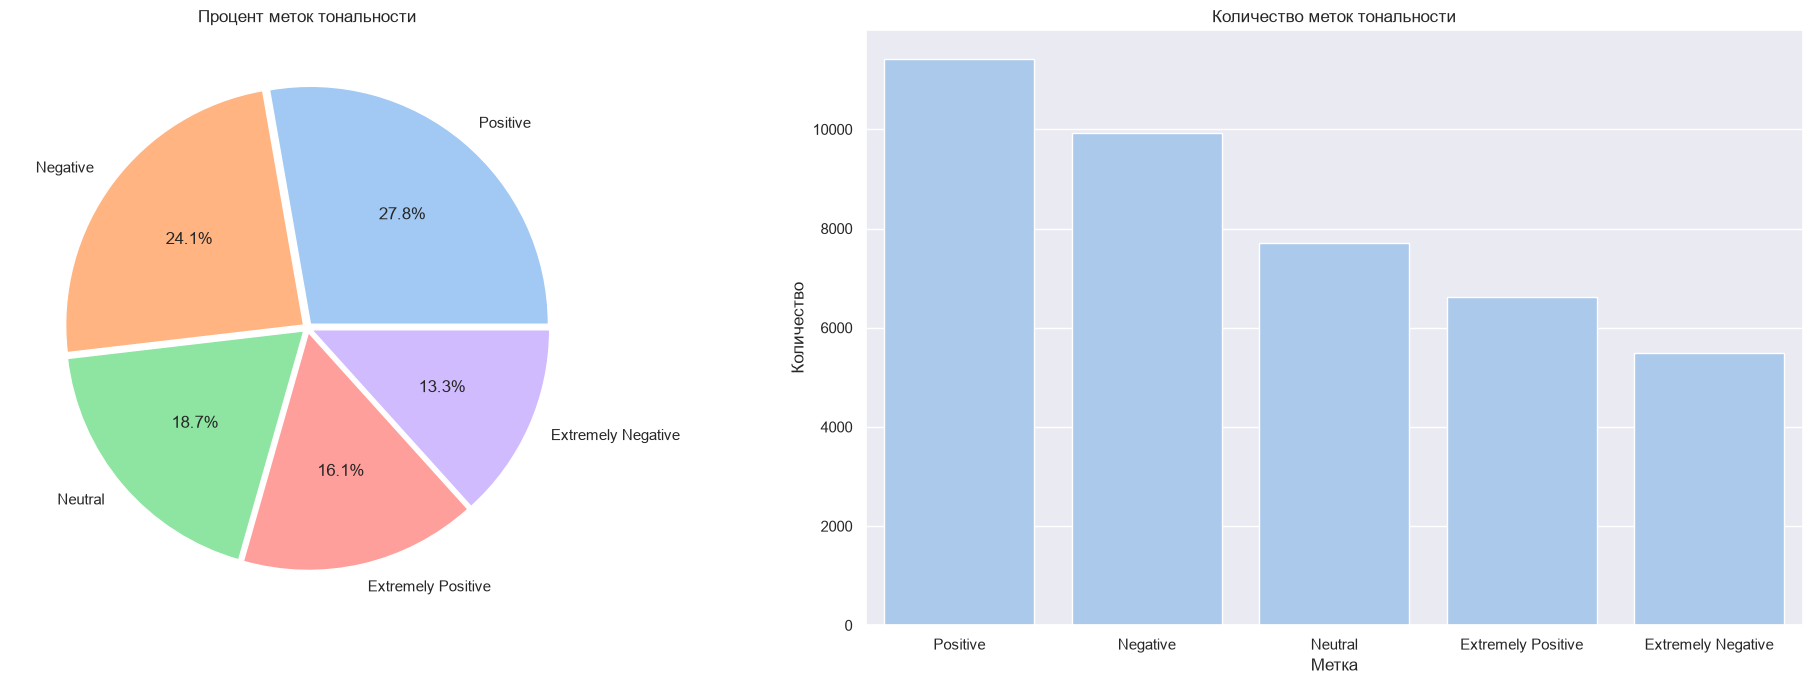

In [21]:
label_count = df['Sentiment'].value_counts()
print(label_count)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (20,7))
sns.set_theme(style='darkgrid', palette='pastel')
color = sns.color_palette(palette='pastel')
explode = [0.02] * len(label_count)

axes[0].pie(label_count.values, labels = label_count.index, autopct='%1.1f%%', 
            colors = color, explode=explode)
axes[0].set_title('Процент меток тональности')

sns.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Количество меток тональности')
axes[1].set_xlabel('Метка')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()


#### Подсчет длины сообщений

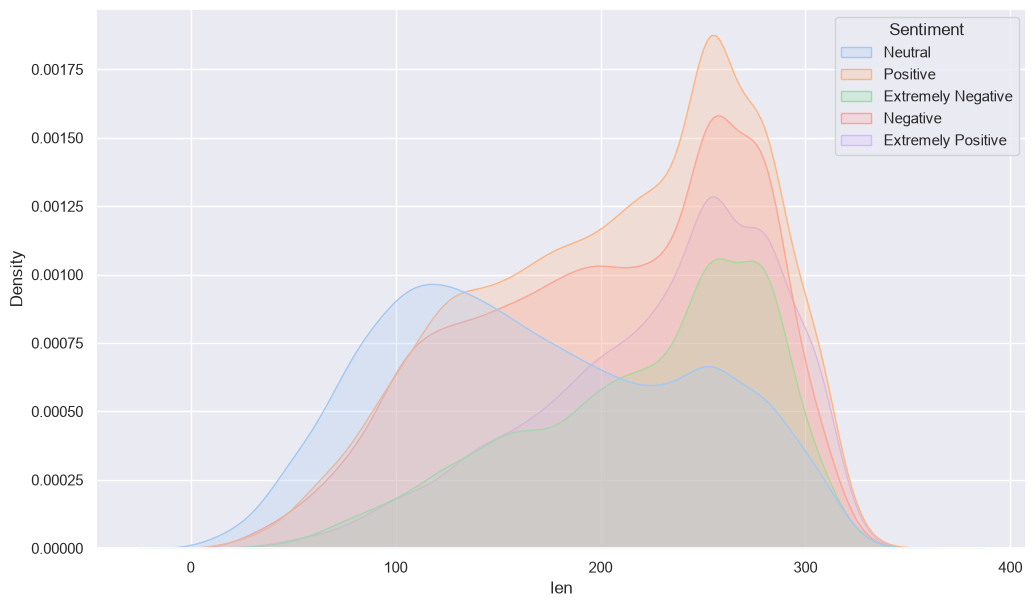

In [23]:
df['len'] = df['OriginalTweet'].apply(len)

plt.figure(figsize=(12, 7))
sns.kdeplot(df, x='len', fill=True, hue='Sentiment')
plt.show()

#### BoW, Bag of Words, Мешок слов

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
matrix = cv.fit_transform(df['OriginalTweet'])

In [25]:
matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1149620 stored elements and shape (41157, 80424)>

In [26]:
matrix.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0]], shape=(41157, 80424))

In [27]:
cv.get_feature_names_out()[67045:67055]

array(['sumantranaik', 'sumbangkan', 'sumer', 'suministros', 'sumitomo',
       'summa', 'summarise', 'summarize', 'summarized', 'summarizes'],
      dtype=object)

In [29]:
word_matrix = pd.DataFrame(matrix.toarray(), columns=cv.get_feature_names_out())

#### Часто встречащиеся слова

In [32]:
df_sum = word_matrix.sum(axis=0, skipna=True)
bow = df_sum.sort_values(ascending=False)[:30]

In [33]:
bow

the            44869
to             38474
co             24121
and            24093
https          24007
of             21547
in             19316
coronavirus    18154
for            14059
19             12597
is             12262
covid          12192
are            11349
you             9717
on              9440
this            7994
prices          7939
at              7850
food            7164
supermarket     7082
store           6917
we              6701
with            6637
it              6636
that            6504
grocery         6283
have            6162
as              6110
be              5753
people          5574
dtype: int64

In [34]:
bow = pd.DataFrame(bow, columns=['Frequncy'])
bow

,Frequncy
the,44869
to,38474
co,24121
and,24093
https,24007
of,21547
in,19316
coronavirus,18154
for,14059
19,12597


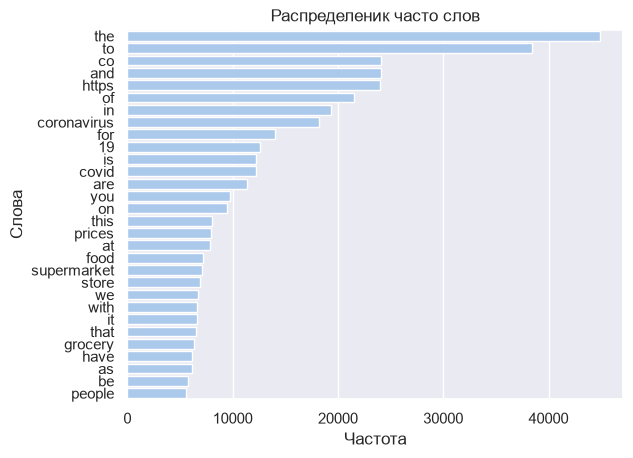

In [35]:
sns.barplot(x=bow['Frequncy'], y=bow.index)
plt.xlabel('Частота')
plt.ylabel('Слова')
plt.title('Распределеник часто слов')
plt.show()

#### Очистка данных

In [37]:
import string
import nltk
import re
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/artemgolubnichiy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [38]:
stopwords = nltk.corpus.stopwords.words('english')

In [39]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\S+", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"pic.\S+", "", text)
    text = re.sub(r"[^a-z'A-Z]", " ", text)
    text = re.sub(r"\s+ [a-z'A-Z]", " ", text+ " ")
    text = ''.join([i for i in text if i not in string.punctuation])
    words = nltk.tokenize.word_tokenize(text)
    text = ' '.join([i for i in words if i not in stopwords and len(i) > 2])
    text = re.sub("\s[\s]+", " ", text).strip()
    return text


In [40]:
df['new_text'] = df['OriginalTweet'].apply(clean_text)

In [41]:
df

,OriginalTweet,Sentiment,len,new_text
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia oolworths give elderly i...
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty lease ont panic enough fo...
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,eady supermarket ovid utbreak paranoid food st...
...,...,...,...,...
41152,Airline pilots offering to stock supermarket s...,Neutral,102,airline pilots offering stock supermarket shel...
41153,Response to complaint not provided citing COVI...,Extremely Negative,138,response complaint provided citing covid elate...
41154,You know itÂs getting tough when @KameronWild...,Positive,136,know getting tough rationing toilet paper oron...
41155,Is it wrong that the smell of hand sanitizer i...,Neutral,111,wrong smell hand sanitizer starting turn orona...


#### Стемминг

In [42]:
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

ps = PorterStemmer()
words = word_tokenize(df['new_text'].iloc[1])
for w in words:
    print(w, ":", ps.stem(w))

advice : advic
talk : talk
neighbours : neighbour
family : famili
exchange : exchang
phone : phone
numbers : number
create : creat
contact : contact
list : list
phone : phone
numbers : number
neighbours : neighbour
schools : school
employer : employ
chemist : chemist
set : set
online : onlin
shopping : shop
accounts : account
poss : poss
adequate : adequ
supplies : suppli
regular : regular
meds : med
order : order
